![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Research Questions and business case

**Business objective:** A merchandising team is interested in investigating where to prioritize investing in, demographics or tier-based targeting, which product categories and channels drive conversion, what product features predict a customer's purchase, and what drives returns.

**RQ1: Does who the customer is predict purchase?**
Variables: `Age_Group`, `Gender`, `Membership_Level`, `Location_Zone`

**RQ2: Does where and how they shop predict purchase?**
Variables: `Item_Category`, `Brand_Tier`, `Device_Type`, `Traffic_Source`

**RQ3: What does predict purchase?**
Variables: `Wishlist_Flag`, `User_Loyalty_Score`, `Item_Popularity_Score`, `Item_Quality_Score`, `Cart_Add_Count`

**RQ4: Among purchases, what predicts a return?**
Variables: `Item_Quality_Score`, `Customer_Rating`, `Item_Category`, `Discount_Percentage`, `Item_Price`

---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

**Dataset:** E-commerce Recommendation Dataset. Number of rows: 12,000. One row: user-item interactions, normalized into a star schema (1 fact table + 8 lookup tables) in `data/project.db`.


![ERD](../ERD.png)

---
## 3. Analysis


**RQ1 | Q1: Does membership level predict purchase conversion?**

In [11]:
query_1 = """
    SELECT
        m.membership_level AS 'Membership Level',
        COUNT(*) AS 'Total Interactions',
        COUNT(CASE WHEN i.purchase_flag = 1 THEN 1 END) AS 'Purchase Count',
        ROUND(AVG(i.purchase_flag) * 100, 2) AS 'Conversion Pct'			-- The fraction of interactions that were purchases in %
    FROM interactions i
    JOIN membership_levels m 
        ON i.membership_id = m.membership_id
    GROUP BY m.membership_level
    ORDER BY ROUND(AVG(i.purchase_flag) * 100, 2) DESC
;
"""
q1_result = run_query(query_1)
q1_result

,Membership Level,Total Interactions,Purchase Count,Conversion Pct
0,Basic,5145,1958,38.06
1,Gold,2445,912,37.30
2,Silver,3345,1207,36.08
3,Platinum,1065,367,34.46


Q1 takeaway: The conversion across all membership levels is quite close, without big differences. However, Basic seems to be the highest one, not Platinum. 

**RQ1 Finding: Overall No.** 

The conversion across all membership levels is quite close, without big differences. None of the customer demographic characteristic tested show real association with purchase. Therefore, 'Who the customer is' does not predict purchase behavior.

**RQ2 | Q2: Which item categories have the highest conversion?**

In [12]:
query_2 = """
    SELECT
        c.item_category AS 'Item Category',
        COUNT(*) AS 'Total Interactions',
        ROUND(AVG(i.purchase_flag) * 100, 2) AS 'Conversion Pct'
    FROM interactions i
    JOIN item_categories c 
        ON i.category_id = c.category_id
    GROUP BY c.item_category
    HAVING COUNT(*) > 500
    ORDER BY ROUND(AVG(i.purchase_flag) * 100, 2) DESC
    ;
"""
q2_result = run_query(query_2)
q2_result

,Item Category,Total Interactions,Conversion Pct
0,Automotive,1167,39.59
1,Home Decor,1209,38.13
2,Books,1213,37.59
3,Beauty,1223,37.45
4,Fashion,1192,36.91
5,Electronics,1228,36.81
6,Health,1207,36.45
7,Groceries,1172,36.43
8,Sports,1162,36.06
9,Toys,1227,34.96


Q2 takeaway: The Automotive category conversion is higher compared to the Toys category, however there is no big spread among the categories.


**RQ2 Finding: Overall No.**

Conversion rate across categories is quite similar. None of the shoping channel characteristics tested showed a real association with purchase. Therefore 'Where or how the customer shops' does not predict purchase behavior.

**RQ3 | Q3: Does adding an item to wishlist predict purchase?**


In [13]:
query_3 = """
    SELECT 
        CASE WHEN wishlist_flag = 1 THEN 'In Wishlist' 
            ELSE 'Not in Wishlist'
        END AS 'Wishlist Status',
        COUNT(*) AS 'Total Interactions',
        SUM(purchase_flag) AS 'Purchase',
        ROUND(AVG(purchase_flag) * 100, 2) AS 'Conversion Pct'
    FROM interactions
    GROUP BY wishlist_flag
    ORDER BY ROUND(AVG(purchase_flag) * 100, 2) DESC
    ;
"""
q3_result = run_query(query_3)
q3_result

,Wishlist Status,Total Interactions,Purchase,Conversion Pct
0,In Wishlist,3974,2733,68.77
1,Not in Wishlist,8026,1711,21.32


Q3 takeaway: Wishlisted items have a higher conversion, 68.8% versus 21.3% for items that were not in a wishlist.

**RQ3 | Q4: Does higher user loyalty score predict purchase?**

In [14]:
query_4 = """
    SELECT 
	CASE 
		WHEN user_loyalty_score < 0.44 THEN 'Low'		-- scores bands are based on the finding in pandas: non-purchase median score is 0.44 and purchase median score is 0.69
		WHEN user_loyalty_score < 0.69 THEN 'Medium'
		ELSE 'High' 
	END AS 'Loyalty Score',
	COUNT(*) AS 'Total Interactions',
	ROUND(AVG(purchase_flag) * 100,  2) AS 'Conversion Pct'
FROM interactions
GROUP BY 
	CASE 
		WHEN user_loyalty_score < 0.44 THEN 'Low'
		WHEN user_loyalty_score < 0.69 THEN 'Medium'
		ELSE 'High' 
	END
ORDER BY ROUND(AVG(purchase_flag) * 100,  2) DESC
;
"""
q4_result = run_query(query_4)
q4_result

,Loyalty Score,Total Interactions,Conversion Pct
0,High,3799,57.73
1,Medium,3449,38.07
2,Low,4752,19.74


Q4 takeaway: Users with higher loyalty score (> 0.69) have higher conversions (57.7%) compared to medium and lower tiers.

**RQ3 Finding: Overall Yes.**

Customer behavior and intent signals predict purchase. Wishlist status (3.2x difference, strongest) and user loyalty score (17.1% → 56.6%, monotonic) are the clearest signals, with engagement metrics liek cart adds, rating, item quality/popularity showing smaller but consistent effects in the same direction. 

**Business implication:** merchandising should prioritize intent-based triggers like wishlist reminders, loyalty-tier nurturing over demographic or channel-based targeting.

**RQ4 | Q5: Among purchased items, does item quality predict returns?**

In [15]:
query_5 = """
    SELECT
        CASE 
            WHEN item_quality_score < 0.69 THEN 'Low'
            WHEN item_quality_score < 0.74 THEN 'Medium'
            ELSE 'High'
        END AS 'Item Quality Score',
        COUNT(*) AS 'Total Purchased Items',
        SUM(return_flag) AS ' Number of Returns',
        ROUND(AVG(return_flag) * 100, 2) AS 'Return Rate'
    FROM interactions
    WHERE purchase_flag = 1 
    GROUP BY 
        CASE 
            WHEN item_quality_score < 0.69 THEN 'Low'
            WHEN item_quality_score < 0.74 THEN 'Medium'
            ELSE 'High'
        END
    ORDER BY ROUND(AVG(return_flag) * 100, 2) DESC
    ;
"""
q5_result = run_query(query_5)
q5_result

,Item Quality Score,Total Purchased Items,Number of Returns,Return Rate
0,Low,1866,289,15.49
1,Medium,389,50,12.85
2,High,2189,232,10.60


Q5 takeaway: Even though there isn't a  big difference between the item quality scores level, items with lower quality seem to have slightly higher return rates.

**Q5 Finding: Partially.**

Item quality and rating show a small association with return rate. Price, discount level and category show no relationship at all. 

**Q6: Which item categories' conversion is higher than the overall average?**

In [16]:
query_6 = """
    SELECT 
        c.item_category AS 'Category',
        ROUND(AVG(i.purchase_flag) * 100, 2) AS 'Conversion Pct'
    FROM interactions i
    JOIN item_categories c
        ON i.category_id = c.category_id
    GROUP BY c.item_category
    HAVING AVG(i.purchase_flag) > (SELECT AVG(purchase_flag) FROM interactions)
    ORDER BY ROUND(AVG(i.purchase_flag) * 100, 2) DESC
    ;
"""
q6_result = run_query(query_6)
q6_result

,Category,Conversion Pct
0,Automotive,39.59
1,Home Decor,38.13
2,Books,37.59
3,Beauty,37.45


Q6 takeaway: Four of ten categories (Automotive, Home Decor, Books, Beauty) beat the overall average conversion rate.

**Q7: What category has the highest return rate?**

In [17]:
query_7 = """
    SELECT 
        c.item_category AS 'Category',
        SUM(CASE WHEN i.return_flag = 1 THEN 1 ELSE 0 END) AS 'Return Count',
        ROUND(AVG(i.return_flag) * 100, 2) AS 'Return Rate'
    FROM interactions i
    JOIN item_categories c
        ON i.category_id = c.category_id
    WHERE i.purchase_flag = 1
    GROUP BY c.item_category
    ORDER BY SUM(CASE WHEN i.return_flag = 1 THEN 1 ELSE 0 END) DESC
    LIMIT 1
    ;
"""
q7_result = run_query(query_7)
q7_result

,Category,Return Count,Return Rate
0,Sports,62,14.8


Q7 takeaway: Sports has the highest return rate of all the categories.

**Q8: What age group has the most purchases without returns?**

In [18]:
query_8 = """
    SELECT
        a.age_group,
        COUNT(*) AS 'Count Purchase w/o Return'
    FROM interactions i
    JOIN age_groups a 
        ON i.age_group_id = a.age_group_id
    WHERE i.purchase_flag = 1 
    AND i.return_flag = 0
    GROUP BY a.age_group
    ORDER BY COUNT(*) DESC
    LIMIT 1
    ;
"""
q8_result = run_query(query_8)
q8_result

,age_group,Count Purchase w/o Return
0,25-34,1272


Q8 takeaway: Age group 25-34 has the most purchases without returns. 

---
## 4. Visualisation


Q3 Result - Visualization

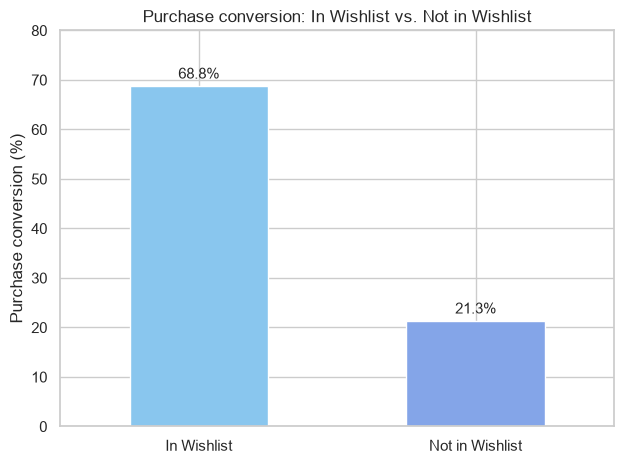

In [25]:
ax = q3_result.set_index('Wishlist Status')['Conversion Pct'].plot(kind='bar', color=["#89C6EE", "#84A5E8"],rot=0)
ax.set_title('Purchase conversion: In Wishlist vs. Not in Wishlist')
ax.set_xlabel('')
ax.set_ylabel('Purchase conversion (%)')
ax.set_ylim(0, 80)
for i, v in enumerate(q3_result['Conversion Pct']):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

**Key Finding:** Items in wishlist convert at 68.8% vs. 21.3% for items not in wishlist — a **3.2x difference**. This is the strongest signal found anywhere in the analysis (Cramér's V = 0.462, "strong". See further details in notebook 01 for the full chi-square test).

Q4 Result - Visualization

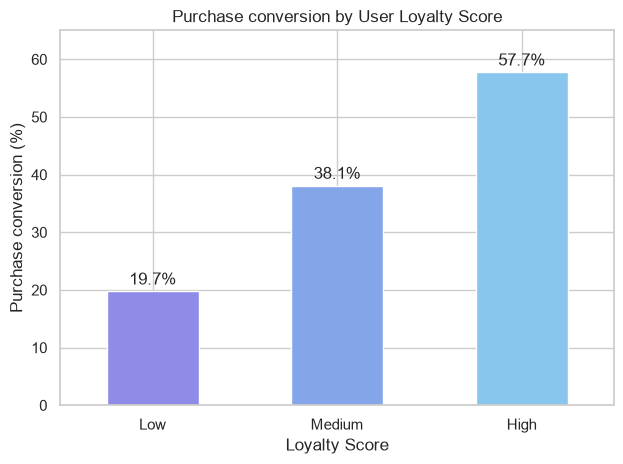

In [32]:
band_order = ['Low', 'Medium', 'High']
plot_data = q4_result.set_index('Loyalty Score').reindex(band_order)['Conversion Pct']

ax = plot_data.plot(kind='bar', color=["#908BE6", "#84A5E8", "#89C6EE"], rot=0)
ax.set_title('Purchase conversion by User Loyalty Score')
ax.set_xlabel('Loyalty Score')
ax.set_ylabel('Purchase conversion (%)')
ax.set_ylim(0, 65)
for i, v in enumerate(plot_data):
    ax.text(i, v + 1.2, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Key Finding:** User Loaylty Score and Purchase conversion have a monotinic relationship, as conversion increases from **19.7%** - Low Loyalty Score, **38.1%** - Medium Loyalty Score, **57.7%** - High Loyalty Score. This is the second strongest purchse predictor identified, after wishlist status.

Q5 Result - Visualization

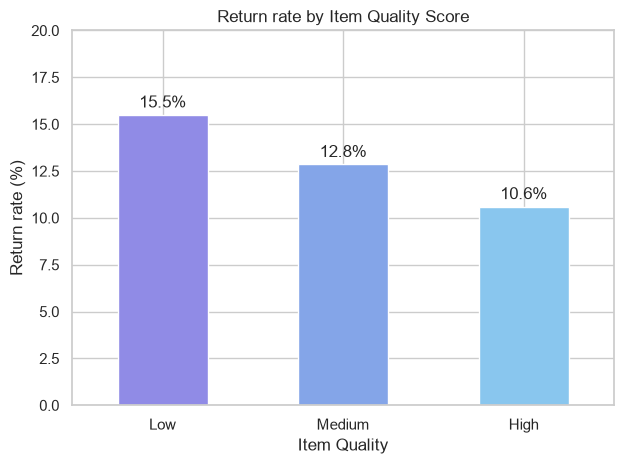

In [33]:
quality_order = ['Low', 'Medium', 'High']
plot_data = q5_result.set_index('Item Quality Score').reindex(quality_order)['Return Rate']

ax = plot_data.plot(kind='bar', color=["#908BE6", "#84A5E8", "#89C6EE"], rot=0)
ax.set_title('Return rate by Item Quality Score')
ax.set_xlabel('Item Quality')
ax.set_ylabel('Return rate (%)')
ax.set_ylim(0, 20)
for i, v in enumerate(plot_data):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

---
## 5. Conclusions


| RQ | Question | Verdict | Key evidence |
|---|---|---|---|
| RQ1 | Does who the customer is predict purchase? | **No** | All four variables (age, gender, tier, location): Cramer's V ≤ 0.025, very weak association |
| RQ2 | Does where and how they shop predict purchase? | **No** | All four variables (category, brand tier, device, traffic source): Cramer's V ≤ 0.025, very weak association |
| RQ3 | What does predict purchase? | **Yes** | All five variables (cart add count, rating, quality, popularity, loyalty score) have high association. Wishlist and Loaylty score have the strongest monotonic relationship. |
| RQ4 | What predicts a return? | **Partially** | All four variables (rating, quality, discount, price) don't show very strong association. Quality is the only varibale that has higher association with returns than the rest. |

**The story:** it's not *who* the customer is or *where* they shop that predicts purchase, rather *what they do* (wishlisting, engagement) and *how loyal they already are*. A merchandising or marketing team working from this data should deprioritize demographic segmentation and channel-specific campaigns, and instead focus on intent-based triggers like wishlist reminders emails, push notificatications, price-drop alerts, and loyalty-tier nurturing. On the product side, quality has a real but modest relationship to returns. Something worth monitoring, but not the dominant driver.

---
## 6. Limitations and next steps


**Limitations:** This is likely a synthetic dataset, so absolute numbers (37% baseline conversion, price ranges) are not real-world benchmarks. The relationships found (wishlist and loyalty as top predictors, demographics and channel as non-predictors) are the deliverables and they demonstrate the analysis method. However, they are not a claim about real shopper behavior.

With more time, I could explore the relationship between stock availability and purchases, some cateogries may show to be out of stock more often leading to lower conversion. Similarly the relationship between click count, engagement score, user loyalty score and purchase could be beneficial to be investigated, which could lead to furhter inshights about the customer's shopping behavior.